In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import fsolve
from scipy.optimize import minimize
from matplotlib import cm

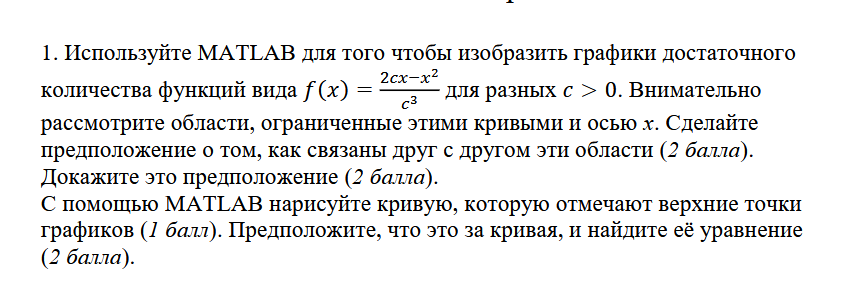

$\frac{2cx-x^2}{c^3} = 0$

$x = 0$ или $x = 2c$

$\int_{0}^{2c}{\frac{2cx-x^2}{c^3} * dx} = \frac{1}{c^3} [cx^2-\frac{x^3}{3}] |^{2c}_{0} = \frac{1}{c^3} * (4c^3-\frac{8c^3}{3}) = \frac{4}{3}$

$f'(x)=\frac{2c-2x}{c^3} = 0$

$x_{max} = c$

$y_{max} = \frac{1}{c}$

$=> y = \frac{1}{x}$

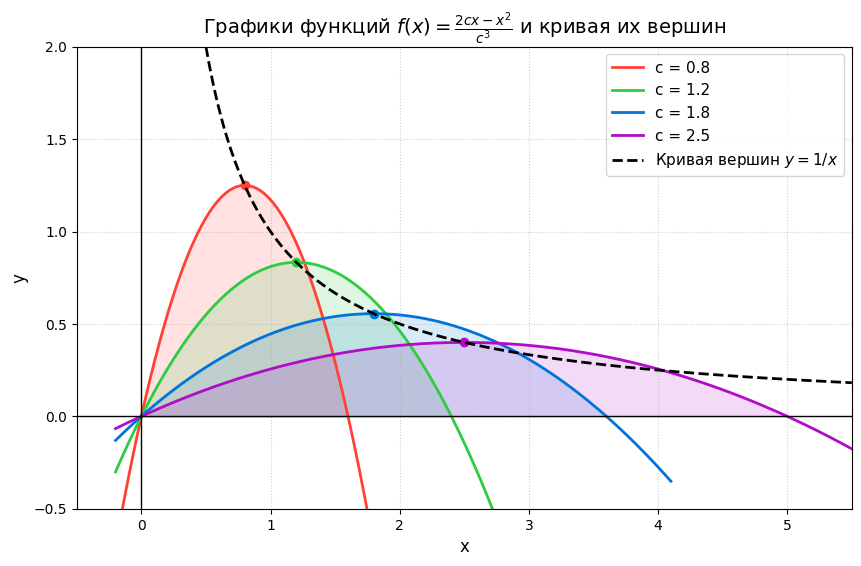

In [4]:
def f(x, c):
    return (2 * c * x - x**2) / (c**3)

def peak_curve(x):
    return 1 / x

plt.figure(figsize=(10, 6))

c_values = [0.8, 1.2, 1.8, 2.5]
colors = ['#FF4136', '#2ECC40', '#0074D9', '#B10DC9']

for c, color in zip(c_values, colors):
    x_fill = np.linspace(0, 2 * c, 200)
    y_fill = f(x_fill, c)
    
    x_plot = np.linspace(-0.2, 2 * c + 0.5, 300)
    y_plot = f(x_plot, c)
    
    plt.plot(x_plot, y_plot, label=f'c = {c}', color=color, linewidth=2)
    plt.fill_between(x_fill, y_fill, 0, color=color, alpha=0.15)
    plt.plot(c, f(c, c), 'o', color=color)

x_peaks = np.linspace(0.5, 5.5, 500)
y_peaks = peak_curve(x_peaks)
plt.plot(x_peaks, y_peaks, '--', color='black', linewidth=2, label=r'Кривая вершин $y = 1/x$')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlim(-0.5, 5.5)
plt.ylim(-0.5, 2.0)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(r'Графики функций $f(x) = \frac{2cx - x^2}{c^3}$ и кривая их вершин', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

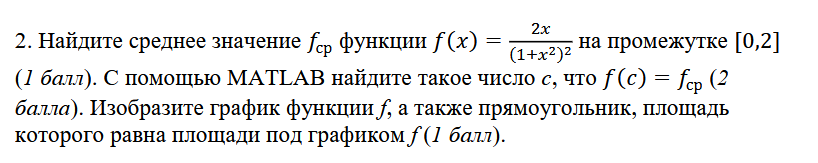

$f_{ср} = \frac{1}{2-0} * \int_{0}^{2}{\frac{2xdx}{(1+x^2)^2}} = \frac{1}{2} * \int_{0}^{2}{\frac{d(1+x^2)}{(1+x^2)^2}} = \frac{1}{2} * (-\frac{1}{(1+x^2)}|^{2}_{0}) = \frac{2}{5}$

Среднее значение f_ср = 0.4
Точка c на промежутке [0, 2]: 1.20684


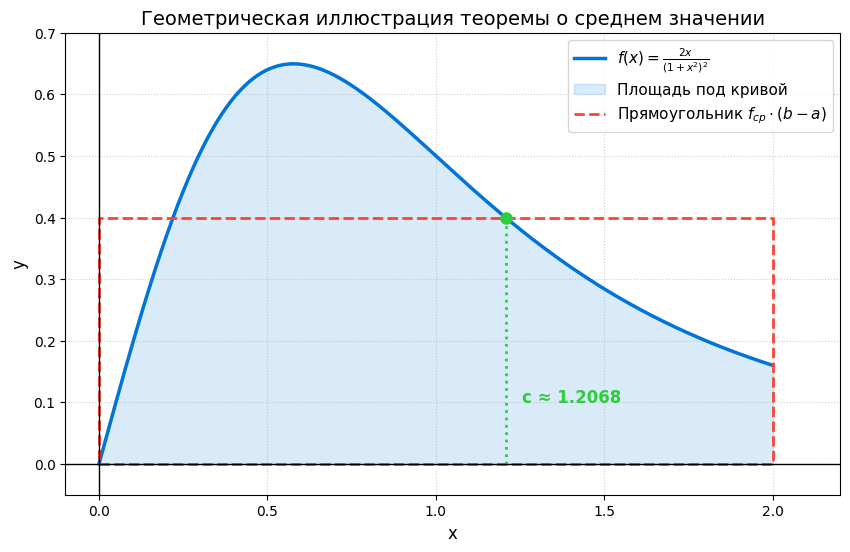

In [6]:
def f(x):
    return (2 * x) / (1 + x**2)**2

a, b = 0, 2
f_cp = 0.4  # Найдено аналитически

equation = lambda x: f(x) - f_cp
c_calculated = fsolve(equation, x0=1.0)[0]

print(f"Среднее значение f_ср = {f_cp}")
print(f"Точка c на промежутке [{a}, {b}]: {c_calculated:.5f}")

x_plot = np.linspace(a, b, 500)
y_plot = f(x_plot)

plt.figure(figsize=(10, 6))

plt.plot(x_plot, y_plot, label=r'$f(x) = \frac{2x}{(1+x^2)^2}$', color='#0074D9', linewidth=2.5)
plt.fill_between(x_plot, y_plot, 0, color='#0074D9', alpha=0.15, label='Площадь под кривой')

rect_x = [a, b, b, a, a]
rect_y = [0, 0, f_cp, f_cp, 0]
plt.plot(rect_x, rect_y, '--', color='#FF4136', linewidth=2, label=r'Прямоугольник $f_{ср} \cdot (b-a)$')

plt.plot(c_calculated, f_cp, 'o', color='#2ECC40', markersize=8, zorder=5)
plt.vlines(c_calculated, 0, f_cp, colors='#2ECC40', linestyles=':', linewidth=2)
plt.text(c_calculated + 0.05, 0.1, f'c ≈ {c_calculated:.4f}', color='#2ECC40', fontsize=12, weight='bold')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlim(-0.1, 2.2)
plt.ylim(-0.05, 0.7)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Геометрическая иллюстрация теоремы о среднем значении', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

plt.show()

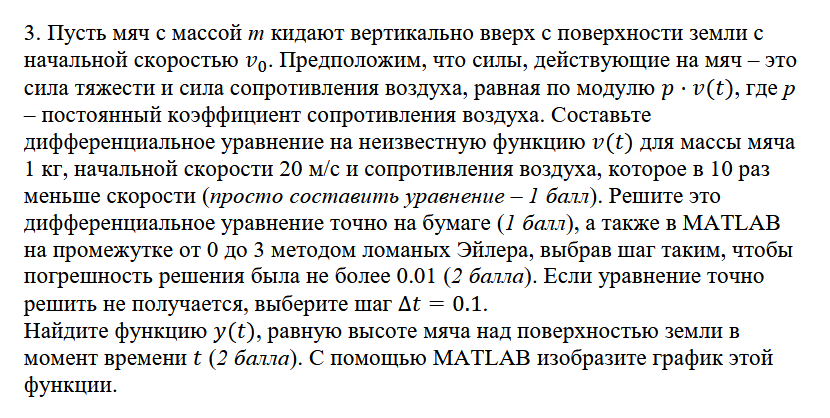

$m\dot{v} = pv + mg$

$\dot{v} = -\frac{v}{10} - 9.8$

$\frac{dv}{9.8+0.1v} = -dt$

$\ln{|9.8+0.1v|} = -0.1v + C_1$

$v(t) = Ce^{-0.1t}-98$

$v(0) = 20 => C = 118$

Потребовался шаг сетки dt = 0.00625
Фактическая максимальная погрешность метода: 0.00820


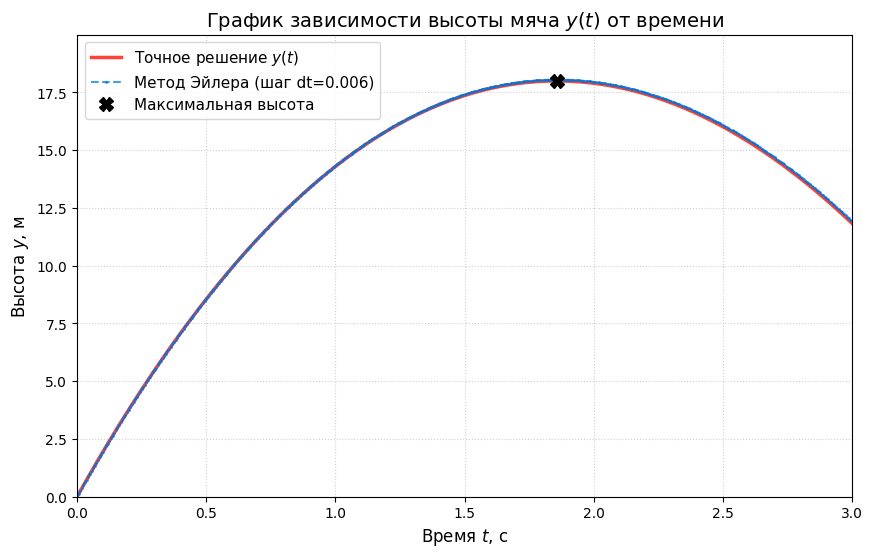

In [9]:
g = 9.8
p = 0.1
m = 1.0
v0 = 20.0
t_start, t_end = 0.0, 3.0

def v_exact(t):
    return 118 * np.exp(-0.1 * t) - 98

def y_exact(t):
    return 1180 * (1 - np.exp(-0.1 * t)) - 98 * t

def f(t, v):
    return -g - (p / m) * v

dt = 0.1
max_error = float('inf')

while max_error > 0.01:
    t_euler = np.arange(t_start, t_end + dt, dt)
    v_euler = np.zeros(len(t_euler))
    y_euler = np.zeros(len(t_euler))
    
    v_euler[0] = v0
    y_euler[0] = 0.0
    
    for i in range(len(t_euler) - 1):
        v_euler[i+1] = v_euler[i] + dt * f(t_euler[i], v_euler[i])
        y_euler[i+1] = y_euler[i] + dt * v_euler[i]
        
    v_true = v_exact(t_euler)
    max_error = np.max(np.abs(v_euler - v_true))
    
    if max_error > 0.01:
        dt /= 2  

print(f"Потребовался шаг сетки dt = {dt:.5f}")
print(f"Фактическая максимальная погрешность метода: {max_error:.5f}")
t_fine = np.linspace(t_start, t_end, 500)
y_fine = y_exact(t_fine)
plt.figure(figsize=(10, 6))
plt.plot(t_fine, y_fine, label='Точное решение $y(t)$', color='#FF4136', linewidth=2.5)
plt.plot(t_euler, y_euler, 'o--', label=f'Метод Эйлера (шаг dt={dt:.3f})', color='#0074D9', markersize=1, alpha=0.7)
t_max = -10 * np.log(98 / 118)
if t_start <= t_max <= t_end:
    plt.plot(t_max, y_exact(t_max), 'X', color='black', markersize=10, label='Максимальная высота')

plt.title('График зависимости высоты мяча $y(t)$ от времени', fontsize=14)
plt.xlabel('Время $t$, с', fontsize=12)
plt.ylabel('Высота $y$, м', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(t_start, t_end)
plt.ylim(0, np.max(y_fine) + 2)
plt.show()

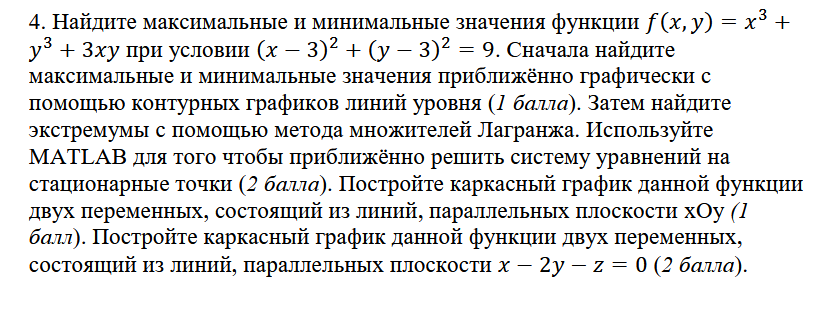

Минимум функции: f(0.8787, 0.8787) = 3.6731
Максимум функции: f(5.1213, 5.1213) = 347.3269


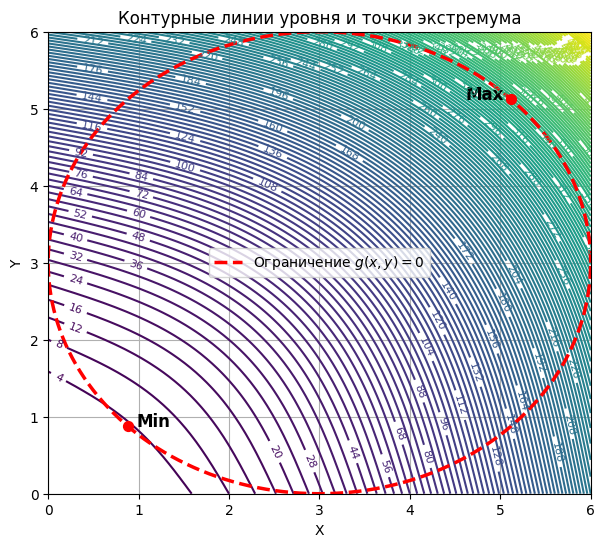

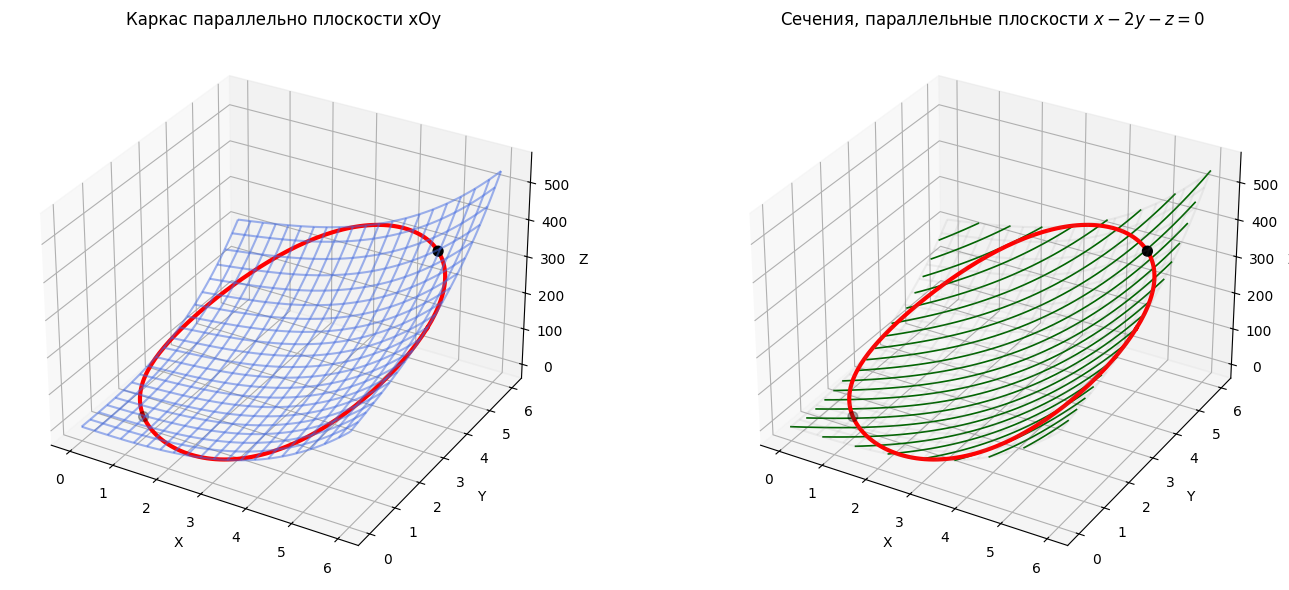

In [6]:
def f(vars):
    x, y = vars
    return x**3 + y**3 + 3*x*y

def constraint(vars):
    x, y = vars
    return (x - 3)**2 + (y - 3)**2 - 9

def f_neg(vars):
    return -f(vars)

cons = {'type': 'eq', 'fun': constraint}
guess_min = [1.0, 1.0]
guess_max = [5.0, 5.0]

res_min = minimize(f, guess_min, constraints=cons)
x_min, y_min = res_min.x
z_min = res_min.fun

res_max = minimize(f_neg, guess_max, constraints=cons)
x_max, y_max = res_max.x
z_max = -res_max.fun

print(f"Минимум функции: f({x_min:.4f}, {y_min:.4f}) = {z_min:.4f}")
print(f"Максимум функции: f({x_max:.4f}, {y_max:.4f}) = {z_max:.4f}")

x_range = np.linspace(0, 6, 100)
y_range = np.linspace(0, 6, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = X**3 + Y**3 + 3*X*Y

theta = np.linspace(0, 2*np.pi, 200)
x_arc = 3 + 3 * np.cos(theta)
y_arc = 3 + 3 * np.sin(theta)
z_arc = x_arc**3 + y_arc**3 + 3*x_arc*y_arc

plt.figure(figsize=(7, 6))
contours = plt.contour(X, Y, Z, levels=150, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)
plt.plot(x_arc, y_arc, 'r--', linewidth=2.5, label='Ограничение $g(x,y)=0$')

plt.scatter([x_min, x_max], [y_min, y_max], color='red', s=50, zorder=5)
plt.text(x_min + 0.1, y_min, 'Min', fontsize=12, fontweight='bold', color='black')
plt.text(x_max - 0.5, y_max, 'Max', fontsize=12, fontweight='bold', color='black')

plt.title('Контурные линии уровня и точки экстремума')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_wireframe(X, Y, Z, rstride=5, cstride=5, color='royalblue', alpha=0.5, label='Поверхность')
ax1.plot(x_arc, y_arc, z_arc, color='red', linewidth=3, label='Условие связи')
ax1.scatter([x_min, x_max], [y_min, y_max], [z_min, z_max], color='black', s=50, zorder=10)
ax1.set_title('Каркас параллельно плоскости xOy')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_wireframe(X, Y, Z, rstride=5, cstride=5, color='gray', alpha=0.1)

for c in np.linspace(-12, 6, 25):
    y_line = np.linspace(0, 6, 100)
    x_line = 2 * y_line + c
    mask = (x_line >= 0) & (x_line <= 6)
    if np.any(mask):
        xl = x_line[mask]
        yl = y_line[mask]
        zl = xl**3 + yl**3 + 3*xl*yl
        ax2.plot(xl, yl, zl, color='darkgreen', linewidth=1.2)

ax2.plot(x_arc, y_arc, z_arc, color='red', linewidth=3, label='Условие связи')
ax2.scatter([x_min, x_max], [y_min, y_max], [z_min, z_max], color='black', s=50, zorder=10)

ax2.set_title('Сечения, параллельные плоскости $x - 2y - z = 0$')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

plt.tight_layout()
plt.show()

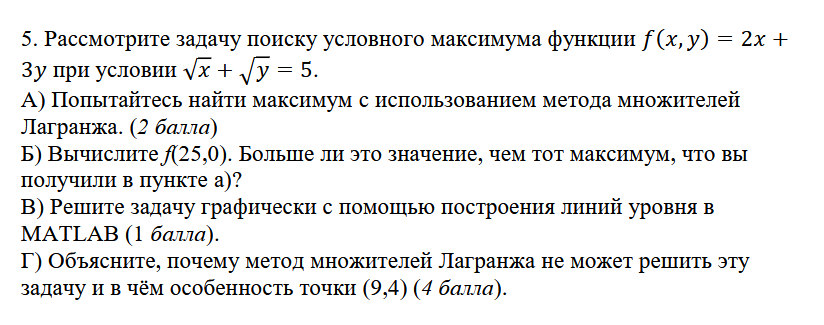

$$L(x,y,\lambda) = 2x+3y-\lambda(\sqrt{x}+\sqrt{y}-5)$$

$$\begin{cases} \frac{\partial L}{\partial x} = 2 - \frac{\lambda}{2\sqrt{x}} = 0 \implies \lambda = 4\sqrt{x} \\ \frac{\partial L}{\partial y} = 3 - \frac{\lambda}{2\sqrt{y}} = 0 \implies \lambda = 6\sqrt{y} \\ \sqrt{x} + \sqrt{y} = 5 \end{cases}$$

$$\sqrt{x} = 1.5\sqrt{y}$$

$$1.5\sqrt{y} + \sqrt{y} = 2.5\sqrt{y} = 5 => \sqrt{y} = 2 => y = 4 => x = 9$$

$$f(9,4) = 30; f(25, 0) = 50$$

$(9,4)$ - условный минимум, метод множителей Лагранжа не умеет проверять точки на границе области

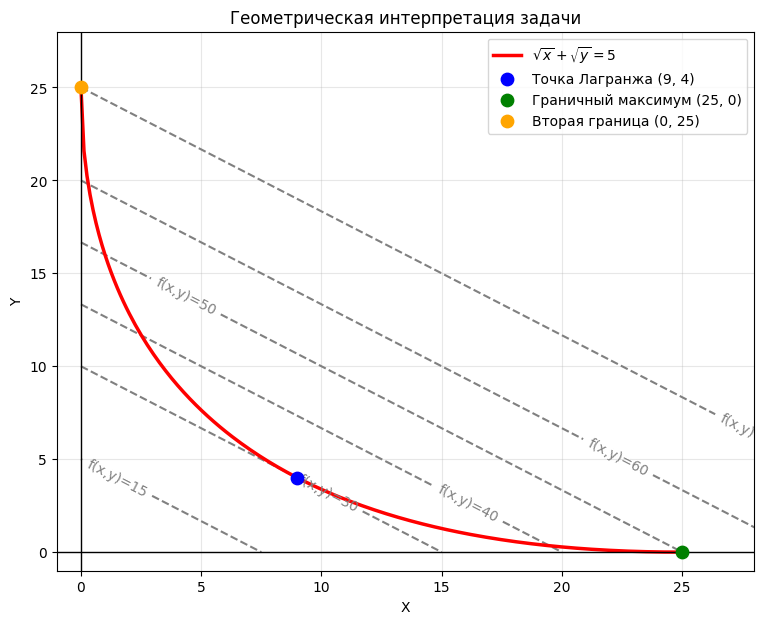

In [7]:
x = np.linspace(0.001, 30, 400)
y = np.linspace(0.001, 30, 400)
X, Y = np.meshgrid(x, y)
Z = 2 * X + 3 * Y

x_constraint = np.linspace(0, 25, 200)
y_constraint = (5 - np.sqrt(x_constraint))**2

plt.figure(figsize=(9, 7))
contours = plt.contour(X, Y, Z, levels=[15, 30, 40, 50, 60, 75], colors='gray', linestyles='dashed')
plt.clabel(contours, inline=True, fmt='f(x,y)=%1.0f', fontsize=10)
plt.plot(x_constraint, y_constraint, color='red', linewidth=2.5, label=r'$\sqrt{x} + \sqrt{y} = 5$')

plt.scatter(9, 4, color='blue', s=80, zorder=5, label='Точка Лагранжа (9, 4)')
plt.scatter(25, 0, color='green', s=80, zorder=5, label='Граничный максимум (25, 0)')
plt.scatter(0, 25, color='orange', s=80, zorder=5, label='Вторая граница (0, 25)')
plt.xlim(-1, 28)
plt.ylim(-1, 28)
plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.title('Геометрическая интерпретация задачи')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()